In [1]:
 # =============================================================================
# CODEALPHA INTERNSHIP — TASK 1: CREDIT SCORING MODEL
# =============================================================================
# Objective : Predict creditworthiness using past financial data
# Algorithms : Logistic Regression, Decision Tree, Random Forest
# Metrics    : Accuracy, Precision, Recall, F1-Score, ROC-AUC
# Platform   : Kaggle Notebook (Python 3)
# =============================================================================

In [2]:
# ── 1. IMPORTS ────────────────────────────────────────────────────────────────
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')
 
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, roc_auc_score, classification_report,
                             confusion_matrix, roc_curve, auc)
from sklearn.impute import SimpleImputer
import os
 
print("✅ All libraries imported successfully!")
print("=" * 60)

✅ All libraries imported successfully!


In [3]:
# ── 2. DATASET ────────────────────────────────────────────────────────────────
# Option A: Use Kaggle's German Credit Dataset (if available on Kaggle)
# kaggle datasets download -d uciml/german-credit
#
# Option B: Synthetic dataset (always works, no download needed)
 
def create_credit_dataset(n=2000, seed=42):
    """Generate a realistic synthetic credit dataset."""
    np.random.seed(seed)
    age            = np.random.randint(18, 75, n)
    income         = np.random.normal(55000, 20000, n).clip(10000, 200000).astype(int)
    loan_amount    = np.random.normal(15000, 8000, n).clip(1000, 60000).astype(int)
    loan_term      = np.random.choice([12, 24, 36, 48, 60], n)
    employment_yrs = np.random.randint(0, 30, n)
    num_credits    = np.random.randint(1, 10, n)
    missed_payments= np.random.randint(0, 5, n)
    debt_ratio     = np.random.uniform(0.05, 0.85, n).round(2)
    credit_score   = np.random.randint(300, 850, n)
    has_mortgage   = np.random.randint(0, 2, n)
    has_savings    = np.random.randint(0, 2, n)
 
    # Target: creditworthy = 1, not = 0
    score  = (credit_score / 850) * 40
    score += (income / 200000) * 20
    score -= debt_ratio * 15
    score -= missed_payments * 5
    score += employment_yrs * 0.3
    score += has_savings * 3
    prob   = 1 / (1 + np.exp(-(score - 30) / 5))
    target = (np.random.random(n) < prob).astype(int)
 
    df = pd.DataFrame({
        'Age': age, 'Income': income, 'LoanAmount': loan_amount,
        'LoanTerm': loan_term, 'EmploymentYears': employment_yrs,
        'NumCredits': num_credits, 'MissedPayments': missed_payments,
        'DebtRatio': debt_ratio, 'CreditScore': credit_score,
        'HasMortgage': has_mortgage, 'HasSavings': has_savings,
        'Creditworthy': target
    })
    return df
 
df = create_credit_dataset()
print(f"📦 Dataset shape : {df.shape}")
print(f"🎯 Class balance : {df['Creditworthy'].value_counts().to_dict()}")
print()
print(df.head())

📦 Dataset shape : (2000, 12)
🎯 Class balance : {0: 1401, 1: 599}

   Age  Income  LoanAmount  LoanTerm  EmploymentYears  NumCredits  \
0   56  105538        1000        36                4           2   
1   69   44382        1000        24                6           4   
2   46   45211       10145        60               13           2   
3   32   75883       18661        24                2           5   
4   60   68637        1000        36               12           3   

   MissedPayments  DebtRatio  CreditScore  HasMortgage  HasSavings  \
0               1       0.08          638            1           1   
1               0       0.53          811            1           1   
2               2       0.55          565            0           0   
3               3       0.47          486            0           0   
4               1       0.66          339            0           1   

   Creditworthy  
0             0  
1             0  
2             0  
3             0  
4       


📊 EXPLORATORY DATA ANALYSIS
           Age     Income  LoanAmount  LoanTerm  EmploymentYears  NumCredits  \
count  2000.00    2000.00     2000.00   2000.00          2000.00     2000.00   
mean     46.36   55996.48    14871.76     35.06            14.80        5.05   
std      16.42   19468.85     7743.23     17.27             8.64        2.57   
min      18.00   10000.00     1000.00     12.00             0.00        1.00   
25%      32.00   42574.00     9259.50     24.00             7.00        3.00   
50%      46.50   55647.50    14899.00     36.00            15.00        5.00   
75%      61.00   68667.25    20182.75     48.00            22.00        7.00   
max      74.00  118862.00    46409.00     60.00            29.00        9.00   

       MissedPayments  DebtRatio  CreditScore  HasMortgage  HasSavings  \
count         2000.00    2000.00      2000.00      2000.00     2000.00   
mean             1.99       0.45       576.67         0.51        0.52   
std              1.42       

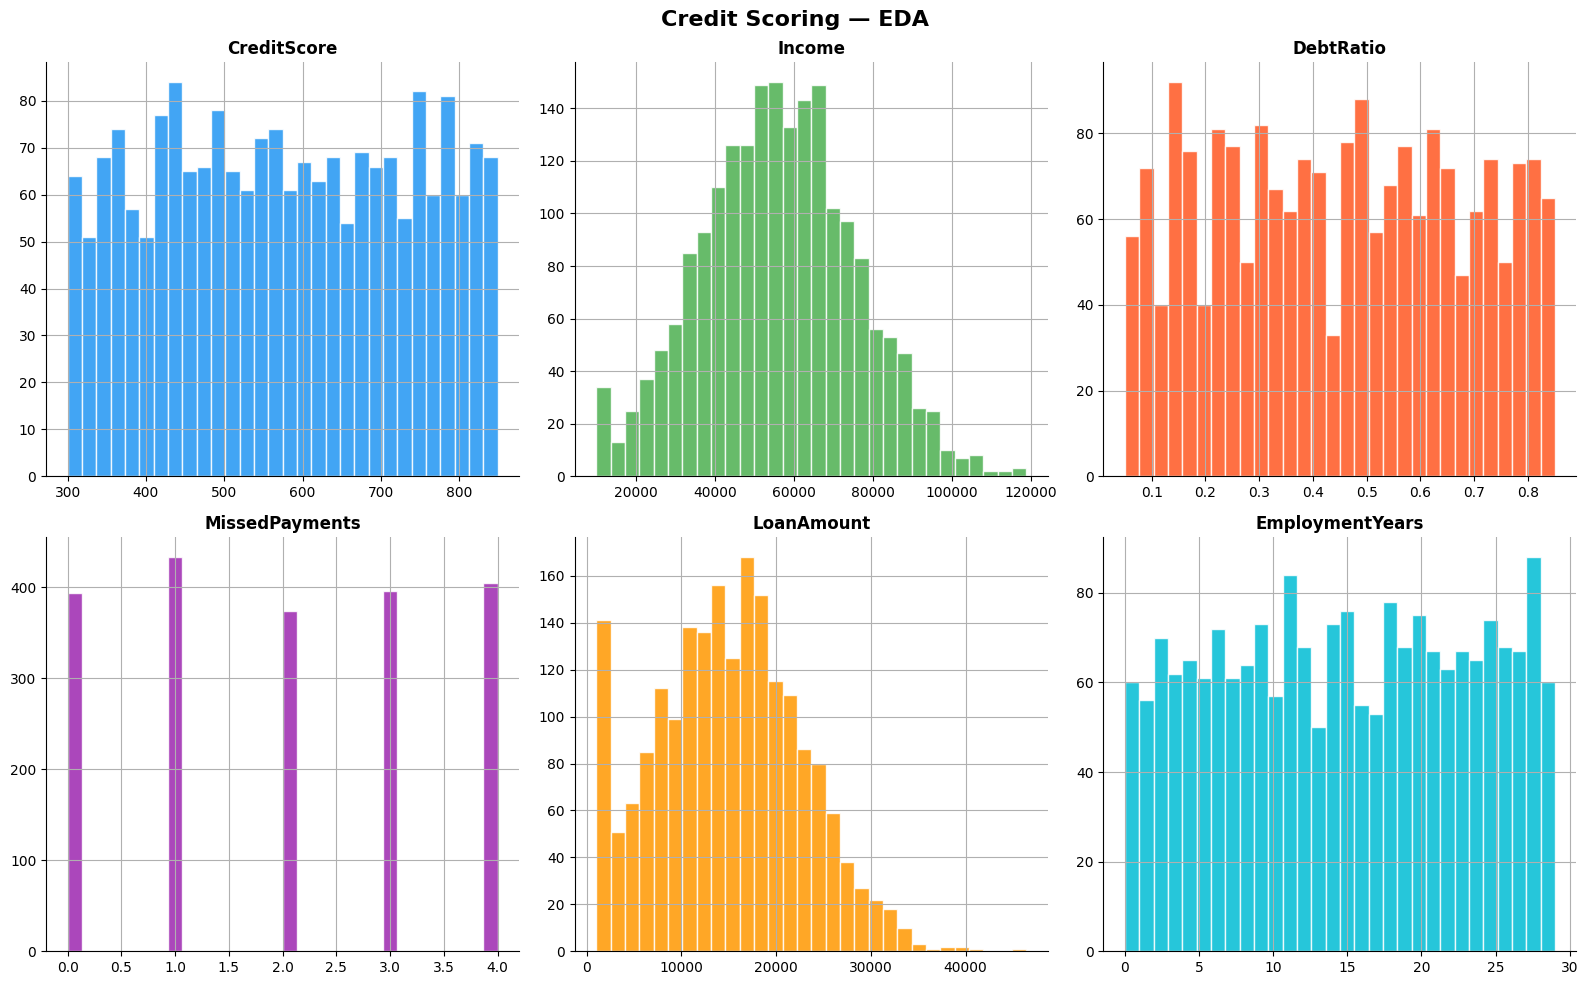

✅ EDA chart saved.


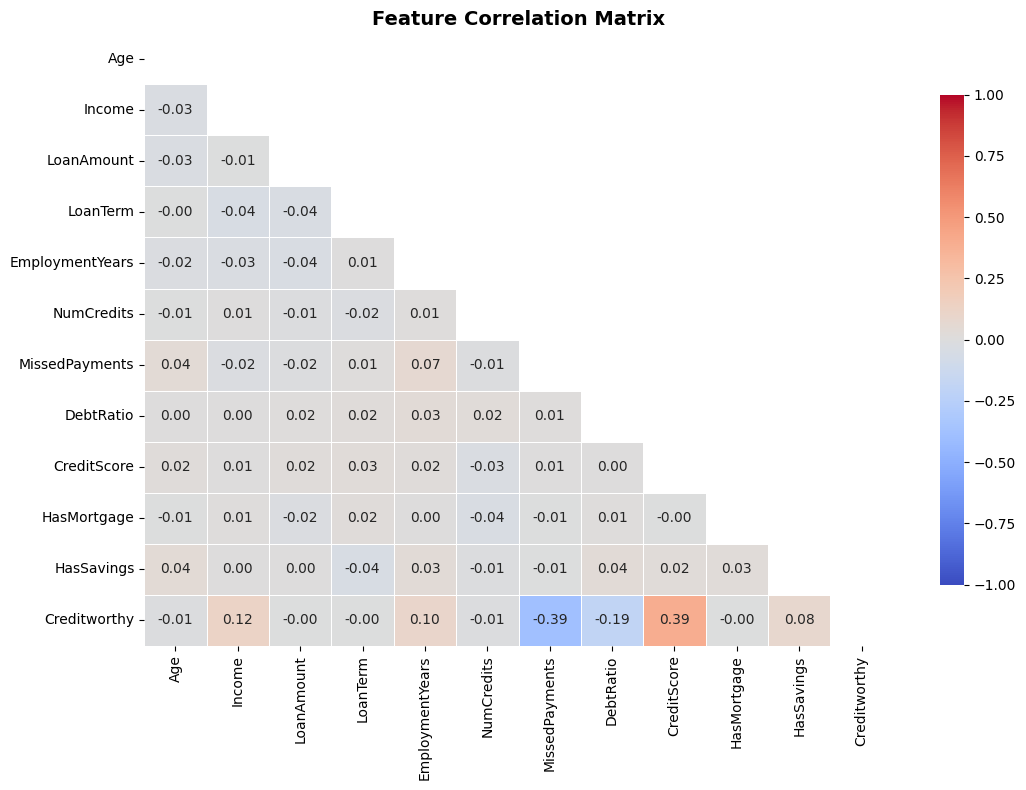

✅ Correlation heatmap saved.


In [4]:
# ── 3. EXPLORATORY DATA ANALYSIS ──────────────────────────────────────────────
print("\n📊 EXPLORATORY DATA ANALYSIS")
print("=" * 60)
print(df.describe().round(2))
print(f"\nMissing values:\n{df.isnull().sum()}")
 
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
fig.suptitle('Credit Scoring — EDA', fontsize=16, fontweight='bold')
 
# Distribution of key features
features_to_plot = ['CreditScore', 'Income', 'DebtRatio',
                    'MissedPayments', 'LoanAmount', 'EmploymentYears']
colors = ['#2196F3', '#4CAF50', '#FF5722', '#9C27B0', '#FF9800', '#00BCD4']
 
for ax, feat, col in zip(axes.flatten(), features_to_plot, colors):
    df[feat].hist(ax=ax, bins=30, color=col, edgecolor='white', alpha=0.85)
    ax.set_title(feat, fontweight='bold')
    ax.set_xlabel('')
    ax.spines[['top','right']].set_visible(False)
 
plt.tight_layout()
plt.savefig('eda_distributions.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ EDA chart saved.")
 
# Correlation heatmap
plt.figure(figsize=(11, 8))
corr = df.corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='coolwarm',
            linewidths=0.5, vmin=-1, vmax=1, cbar_kws={'shrink': 0.8})
plt.title('Feature Correlation Matrix', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('correlation_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Correlation heatmap saved.")


In [5]:
# ── 4. FEATURE ENGINEERING ────────────────────────────────────────────────────
print("\n🔧 FEATURE ENGINEERING")
print("=" * 60)
 
df['DebtToIncome']      = (df['LoanAmount'] / df['Income']).round(4)
df['MonthlyPayment']    = (df['LoanAmount'] / df['LoanTerm']).round(2)
df['PaymentToIncome']   = (df['MonthlyPayment'] / (df['Income'] / 12)).round(4)
df['CreditUtilization'] = df['DebtRatio'] * df['NumCredits']
df['RiskScore']         = (df['MissedPayments'] * 10 + df['DebtRatio'] * 20).round(2)
 
print(f"New features added: DebtToIncome, MonthlyPayment, PaymentToIncome, "
      f"CreditUtilization, RiskScore")
print(f"Updated dataset shape: {df.shape}")



🔧 FEATURE ENGINEERING
New features added: DebtToIncome, MonthlyPayment, PaymentToIncome, CreditUtilization, RiskScore
Updated dataset shape: (2000, 17)


In [6]:
# ── 5. PREPROCESSING ──────────────────────────────────────────────────────────
X = df.drop('Creditworthy', axis=1)
y = df['Creditworthy']
 
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y)
 
scaler  = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s  = scaler.transform(X_test)
 
print(f"\nTrain size : {X_train.shape[0]} | Test size : {X_test.shape[0]}")


Train size : 1600 | Test size : 400


In [7]:
# ── 6. MODEL TRAINING ─────────────────────────────────────────────────────────
print("\n🤖 MODEL TRAINING")
print("=" * 60)
 
models = {
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42),
    'Decision Tree'      : DecisionTreeClassifier(max_depth=6, random_state=42),
    'Random Forest'      : RandomForestClassifier(n_estimators=200, max_depth=8,
                                                   random_state=42, n_jobs=-1),
    'Gradient Boosting'  : GradientBoostingClassifier(n_estimators=200, max_depth=4,
                                                       learning_rate=0.08, random_state=42)
}
 
results = {}
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
 
for name, model in models.items():
    # Logistic Regression uses scaled data; trees use raw
    Xtr = X_train_s if name == 'Logistic Regression' else X_train
    Xte = X_test_s  if name == 'Logistic Regression' else X_test
 
    model.fit(Xtr, y_train)
    y_pred = model.predict(Xte)
    y_prob = model.predict_proba(Xte)[:, 1]
 
    cv_scores = cross_val_score(model, Xtr, y_train, cv=skf, scoring='roc_auc')
 
    results[name] = {
        'Accuracy' : accuracy_score(y_test, y_pred),
        'Precision': precision_score(y_test, y_pred),
        'Recall'   : recall_score(y_test, y_pred),
        'F1-Score' : f1_score(y_test, y_pred),
        'ROC-AUC'  : roc_auc_score(y_test, y_prob),
        'CV-AUC'   : cv_scores.mean(),
        'y_prob'   : y_prob,
        'y_pred'   : y_pred,
        'model'    : model
    }
    print(f"  ✅ {name:<25} | AUC={results[name]['ROC-AUC']:.4f} "
          f"| CV-AUC={results[name]['CV-AUC']:.4f}")


🤖 MODEL TRAINING
  ✅ Logistic Regression       | AUC=0.8845 | CV-AUC=0.8854
  ✅ Decision Tree             | AUC=0.8108 | CV-AUC=0.7862
  ✅ Random Forest             | AUC=0.8597 | CV-AUC=0.8592
  ✅ Gradient Boosting         | AUC=0.8542 | CV-AUC=0.8511


In [8]:
# ── 7. RESULTS TABLE ──────────────────────────────────────────────────────────
print("\n📋 MODEL COMPARISON")
print("=" * 60)
metrics_df = pd.DataFrame({
    k: {m: v for m, v in v.items() if m not in ('y_prob', 'y_pred', 'model')}
    for k, v in results.items()
}).T.round(4)
print(metrics_df.to_string())


📋 MODEL COMPARISON
                     Accuracy  Precision  Recall  F1-Score  ROC-AUC  CV-AUC
Logistic Regression    0.8500     0.7679  0.7167    0.7414   0.8845  0.8854
Decision Tree          0.7800     0.6194  0.6917    0.6535   0.8108  0.7862
Random Forest          0.8250     0.7358  0.6500    0.6903   0.8597  0.8592
Gradient Boosting      0.8125     0.6800  0.7083    0.6939   0.8542  0.8511


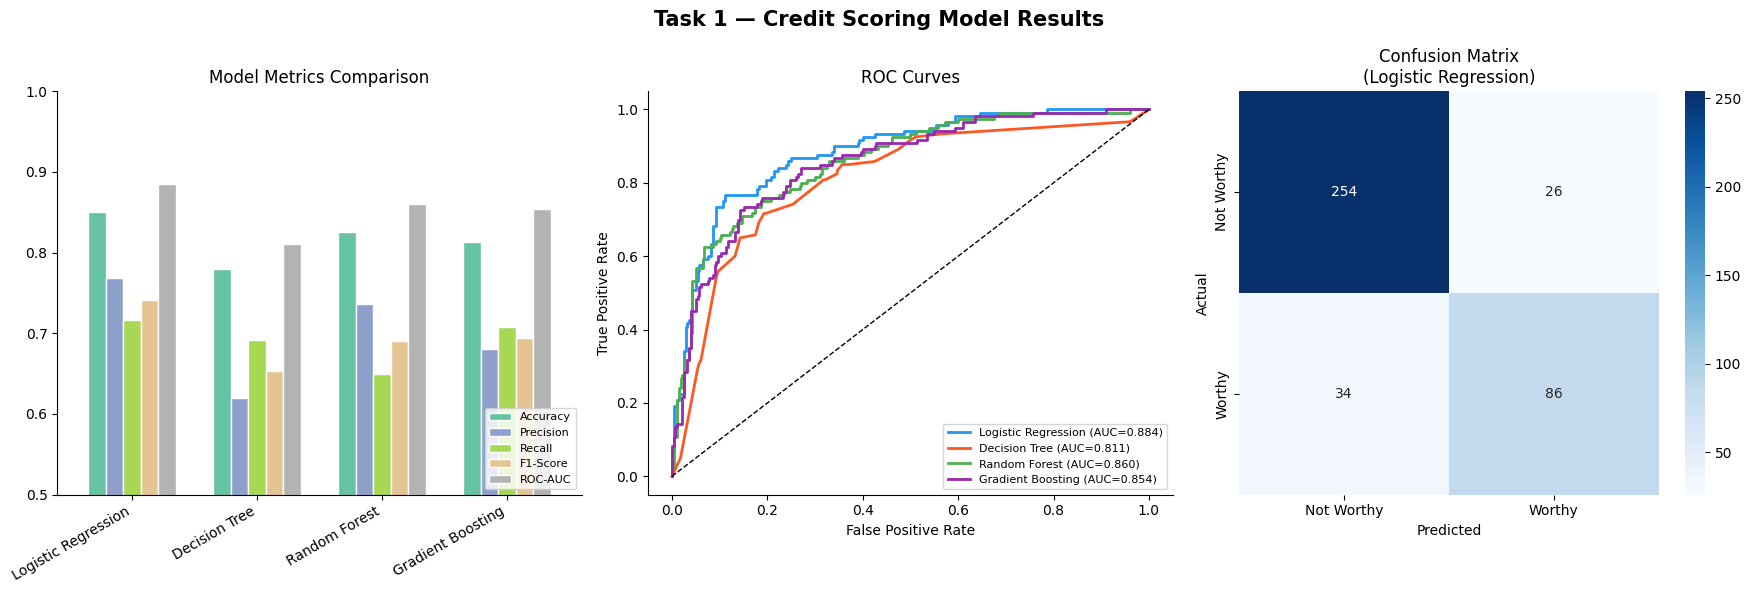


🏆 Best Model: Logistic Regression  (ROC-AUC = 0.8845)


In [9]:
# ── 8. VISUALISATIONS ─────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
fig.suptitle('Task 1 — Credit Scoring Model Results', fontsize=15, fontweight='bold')
 
# (a) Metrics bar chart
metrics_df[['Accuracy','Precision','Recall','F1-Score','ROC-AUC']].plot(
    kind='bar', ax=axes[0], colormap='Set2', edgecolor='white', width=0.7)
axes[0].set_title('Model Metrics Comparison')
axes[0].set_ylim(0.5, 1.0)
axes[0].set_xticklabels(axes[0].get_xticklabels(), rotation=30, ha='right')
axes[0].legend(loc='lower right', fontsize=8)
axes[0].spines[['top','right']].set_visible(False)
 
# (b) ROC curves
colors_roc = ['#2196F3','#FF5722','#4CAF50','#9C27B0']
for (name, res), c in zip(results.items(), colors_roc):
    fpr, tpr, _ = roc_curve(y_test, res['y_prob'])
    axes[1].plot(fpr, tpr, color=c, lw=2,
                 label=f"{name} (AUC={res['ROC-AUC']:.3f})")
axes[1].plot([0,1],[0,1],'k--', lw=1)
axes[1].set_xlabel('False Positive Rate'); axes[1].set_ylabel('True Positive Rate')
axes[1].set_title('ROC Curves')
axes[1].legend(fontsize=8); axes[1].spines[['top','right']].set_visible(False)
 
# (c) Confusion matrix for best model
best_name = metrics_df['ROC-AUC'].idxmax()
cm = confusion_matrix(y_test, results[best_name]['y_pred'])
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[2],
            xticklabels=['Not Worthy','Worthy'],
            yticklabels=['Not Worthy','Worthy'])
axes[2].set_title(f'Confusion Matrix\n({best_name})')
axes[2].set_xlabel('Predicted'); axes[2].set_ylabel('Actual')
 
plt.tight_layout()
plt.savefig('task1_results.png', dpi=150, bbox_inches='tight')
plt.show()
print(f"\n🏆 Best Model: {best_name}  (ROC-AUC = {metrics_df['ROC-AUC'].max():.4f})")

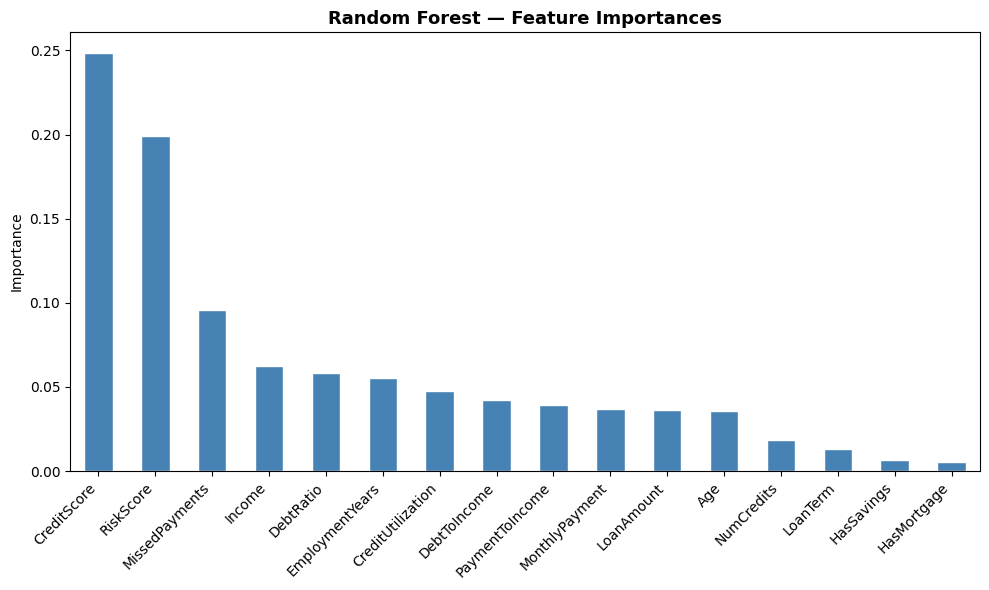


✅ TASK 1 COMPLETE — Credit Scoring Model


In [10]:
# Feature importance for Random Forest
rf_model = results['Random Forest']['model']
feat_imp  = pd.Series(rf_model.feature_importances_, index=X.columns).sort_values(ascending=False)
 
plt.figure(figsize=(10, 6))
feat_imp.plot(kind='bar', color='steelblue', edgecolor='white')
plt.title('Random Forest — Feature Importances', fontsize=13, fontweight='bold')
plt.ylabel('Importance'); plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig('feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()
 
print("\n✅ TASK 1 COMPLETE — Credit Scoring Model")
print("=" * 60)